In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import scienceplots
import os
import glob
import os
import torch
import pickle
import numpy as np
import json
import matplotlib.pyplot as plt
import warnings
import pandas as pd
from math import floor, log10
from tensorboard.backend.event_processing import event_accumulator
import warnings
warnings.filterwarnings("ignore")
plt.style.use(['science','no-latex'])
import matplotlib.pylab as pylab
params = {'figure.dpi': 900,
            'axes.labelsize': 'small',
          'legend.fontsize': 'x-small',
         'axes.titlesize':'medium',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'font.family': 'DejaVu Sans'}
from matplotlib import rc
pylab.rcParams.update(params)

ORANGE = '#ffad33'
PINK = "#FF81C0"
MAGENTA = "#FF00FF"
YELLOW = "#FAC205"
SILVER = "#C5C9C7"
GRAY = "#929591"
DARK_GRAY = "#5b5b5b"
BLUE = "#069AF3"
DARK_BLUE = "#0000FF"
RBLUE = "#0088cc" #"#2d72ed"
RPURPLE = "#5c12de"
RYELLOW = "#dead12"
GREEN = "#56BE25"




def make_tetrapeptide_figures(names, results_dir, split, figure_name, errorbar=False):
  rep_names = ["100ns", "50ns", "30ns", "20ns", "10ns", "5ns", "2ns"]
  proteins = pd.read_csv(split, index_col="name").index
  jsds = {}
  valid_path_rates = {}
  path_probs = {}
  for i, name in enumerate(names):
      full_path = os.path.join(results_dir, f"main_eval_output_{name}")
      
      for protein in proteins:
          # protein_path = os.path.join(full_path, protein)
          # data = pickle.load(open(os.path.join(protein_path, f"{protein}.pkl"), "rb"))
          try:
            data = pickle.load(open(os.path.join(full_path, f"{protein}.pkl"), "rb"))
          except:
            print(f"Could not load {protein}")
            continue
          if i == 0: # only have to go through replicates once
            for rep_name in rep_names:
              if rep_name in jsds.keys():
                jsds[rep_name].append(data[f"{rep_name}_rep_JSD"])
              else:
                jsds[rep_name] = [data[f"{rep_name}_rep_JSD"]]

              if rep_name in valid_path_rates.keys():
                valid_path_rates[rep_name].append(data[f"{rep_name}_rep_valid_rate"])
              else:
                valid_path_rates[rep_name] = [data[f"{rep_name}_rep_valid_rate"]]

              if rep_name in path_probs.keys():
                path_probs[rep_name].append(data[f"{rep_name}_rep_prob"])
              else:
                path_probs[rep_name] = [data[f"{rep_name}_rep_prob"]]

          # Now get data for the method
          if name in jsds.keys():
            jsds[name].append(data["gen_JSD"])
          else:
            jsds[name] = [data["gen_JSD"]]

          if name in valid_path_rates.keys():
            valid_path_rates[name].append(data["gen_valid_rate"])
          else:
            valid_path_rates[name] = [data["gen_valid_rate"]]
          
          if name in path_probs.keys():
            path_probs[name].append(data["gen_prob"])
          else:
            path_probs[name] = [data["gen_prob"]]

  # Average across proteins
  for key in jsds.keys():
    jsds[key] = np.array(jsds[key]).mean()
    valid_path_rates[key] = np.array(valid_path_rates[key]).mean()
    path_probs[key] = np.array(path_probs[key]).mean() 

  # Calculate standard deviations
  jsds_std = {key: values.std() for key, values in jsds.items()}
  valid_path_rates_std = {key: values.std() for key, values in valid_path_rates.items()}
  path_probs_std = {key: values.std() for key, values in path_probs.items()}

  # Combine data into a structure for grouped plotting
  # Prepare data
  methods = names + rep_names
  metrics = ['JSD (↓)', 'Valid Path Rate (↑)', 'Average Path Probability (↑)']  
  data = [
        jsds,
        valid_path_rates,
        path_probs,
    ]

  data_stds = [
    jsds_std,
    valid_path_rates_std,
    path_probs_std,
  ]

  # Define colors
  colors = {
      "100ns": "#ADD8E6",  # Light blue
      "50ns": "#87CEEB",  # Sky blue
      "30ns": "#4682B4",  # Steel blue
      "20ns": "#4169E1",  # Royal blue
      "10ns": "#0000CD",  # Medium blue
      "5ns": "#00008B",   # Dark blue
      "2ns": "#000080"    # Navy blue
  }

  other_colors = [ORANGE, MAGENTA, SILVER, RPURPLE, GREEN, DARK_GRAY]


  # Set up bar positions
  bar_width = 0.1
  n_metrics = len(metrics)
  n_methods = len(methods)
  x = np.arange(n_metrics)

  # Initialize figure and axes
  fig, ax1 = plt.subplots(figsize=(10, 6))
  ax2 = ax1.twinx()  # Secondary y-axis for average path probability

  print(methods)
  for i, method in enumerate(methods):
      if method in colors.keys():
        color = colors[method]
      else:
        color = other_colors.pop(0)
      # Plot JSD and Valid Path Rate (left y-axis)
      ax1.bar(x[0] + i * bar_width*0.4, data[0][method] + 1e-2, bar_width, label=method + " MD" if "ns" in method else method, color=color, yerr=data_stds[0][method] if errorbar else None, capsize=3)
      ax1.bar(x[1] + i * bar_width*0.4, data[1][method]+ 1e-2, bar_width, color=color, yerr=data_stds[1][method] if errorbar else None, capsize=3)

      # Plot Average Path Probability (right y-axis)
      ax2.bar(x[2] + i * bar_width*0.4, data[2][method]+ 1e-3, bar_width, color=color, yerr=data_stds[2][method] if errorbar else None, capsize=3)

  # Add a vertical dotted line between Valid Path Rate and Average Path Probability
  ax1.axvline(x=1.65, color='gray', linestyle='dotted', linewidth=2)

  # Customize axes
  # ax1.set_xlabel("Metrics", fontsize=12)
  ax1.set_ylabel("JSD & Valid Path Rate", fontsize=14)
  ax2.set_ylabel("Average Path Probability", fontsize=14)
  ax1.set_xticks(x + (n_methods - 1) * bar_width / 2)
  custom_positions = [0.15, 1.15, 2.1]  # Centered positions for 'JSD', 'Valid Path Rate', 'Average Path Probability'
  ax1.set_xticks(custom_positions)
  ax1.set_xticklabels(metrics, fontsize=11)
  ax1.legend(fontsize=10, loc="upper left")

  # Title and layout
  # plt.title("Performance Comparison of Methods by Metrics", fontsize=14)
  plt.tight_layout()
  plt.savefig(f"{figure_name}.png")
  plt.show()
      

Could not load HYPI
['om_interpolate_initial_guess_level=100', '100ns', '50ns', '30ns', '20ns', '10ns', '5ns', '2ns']


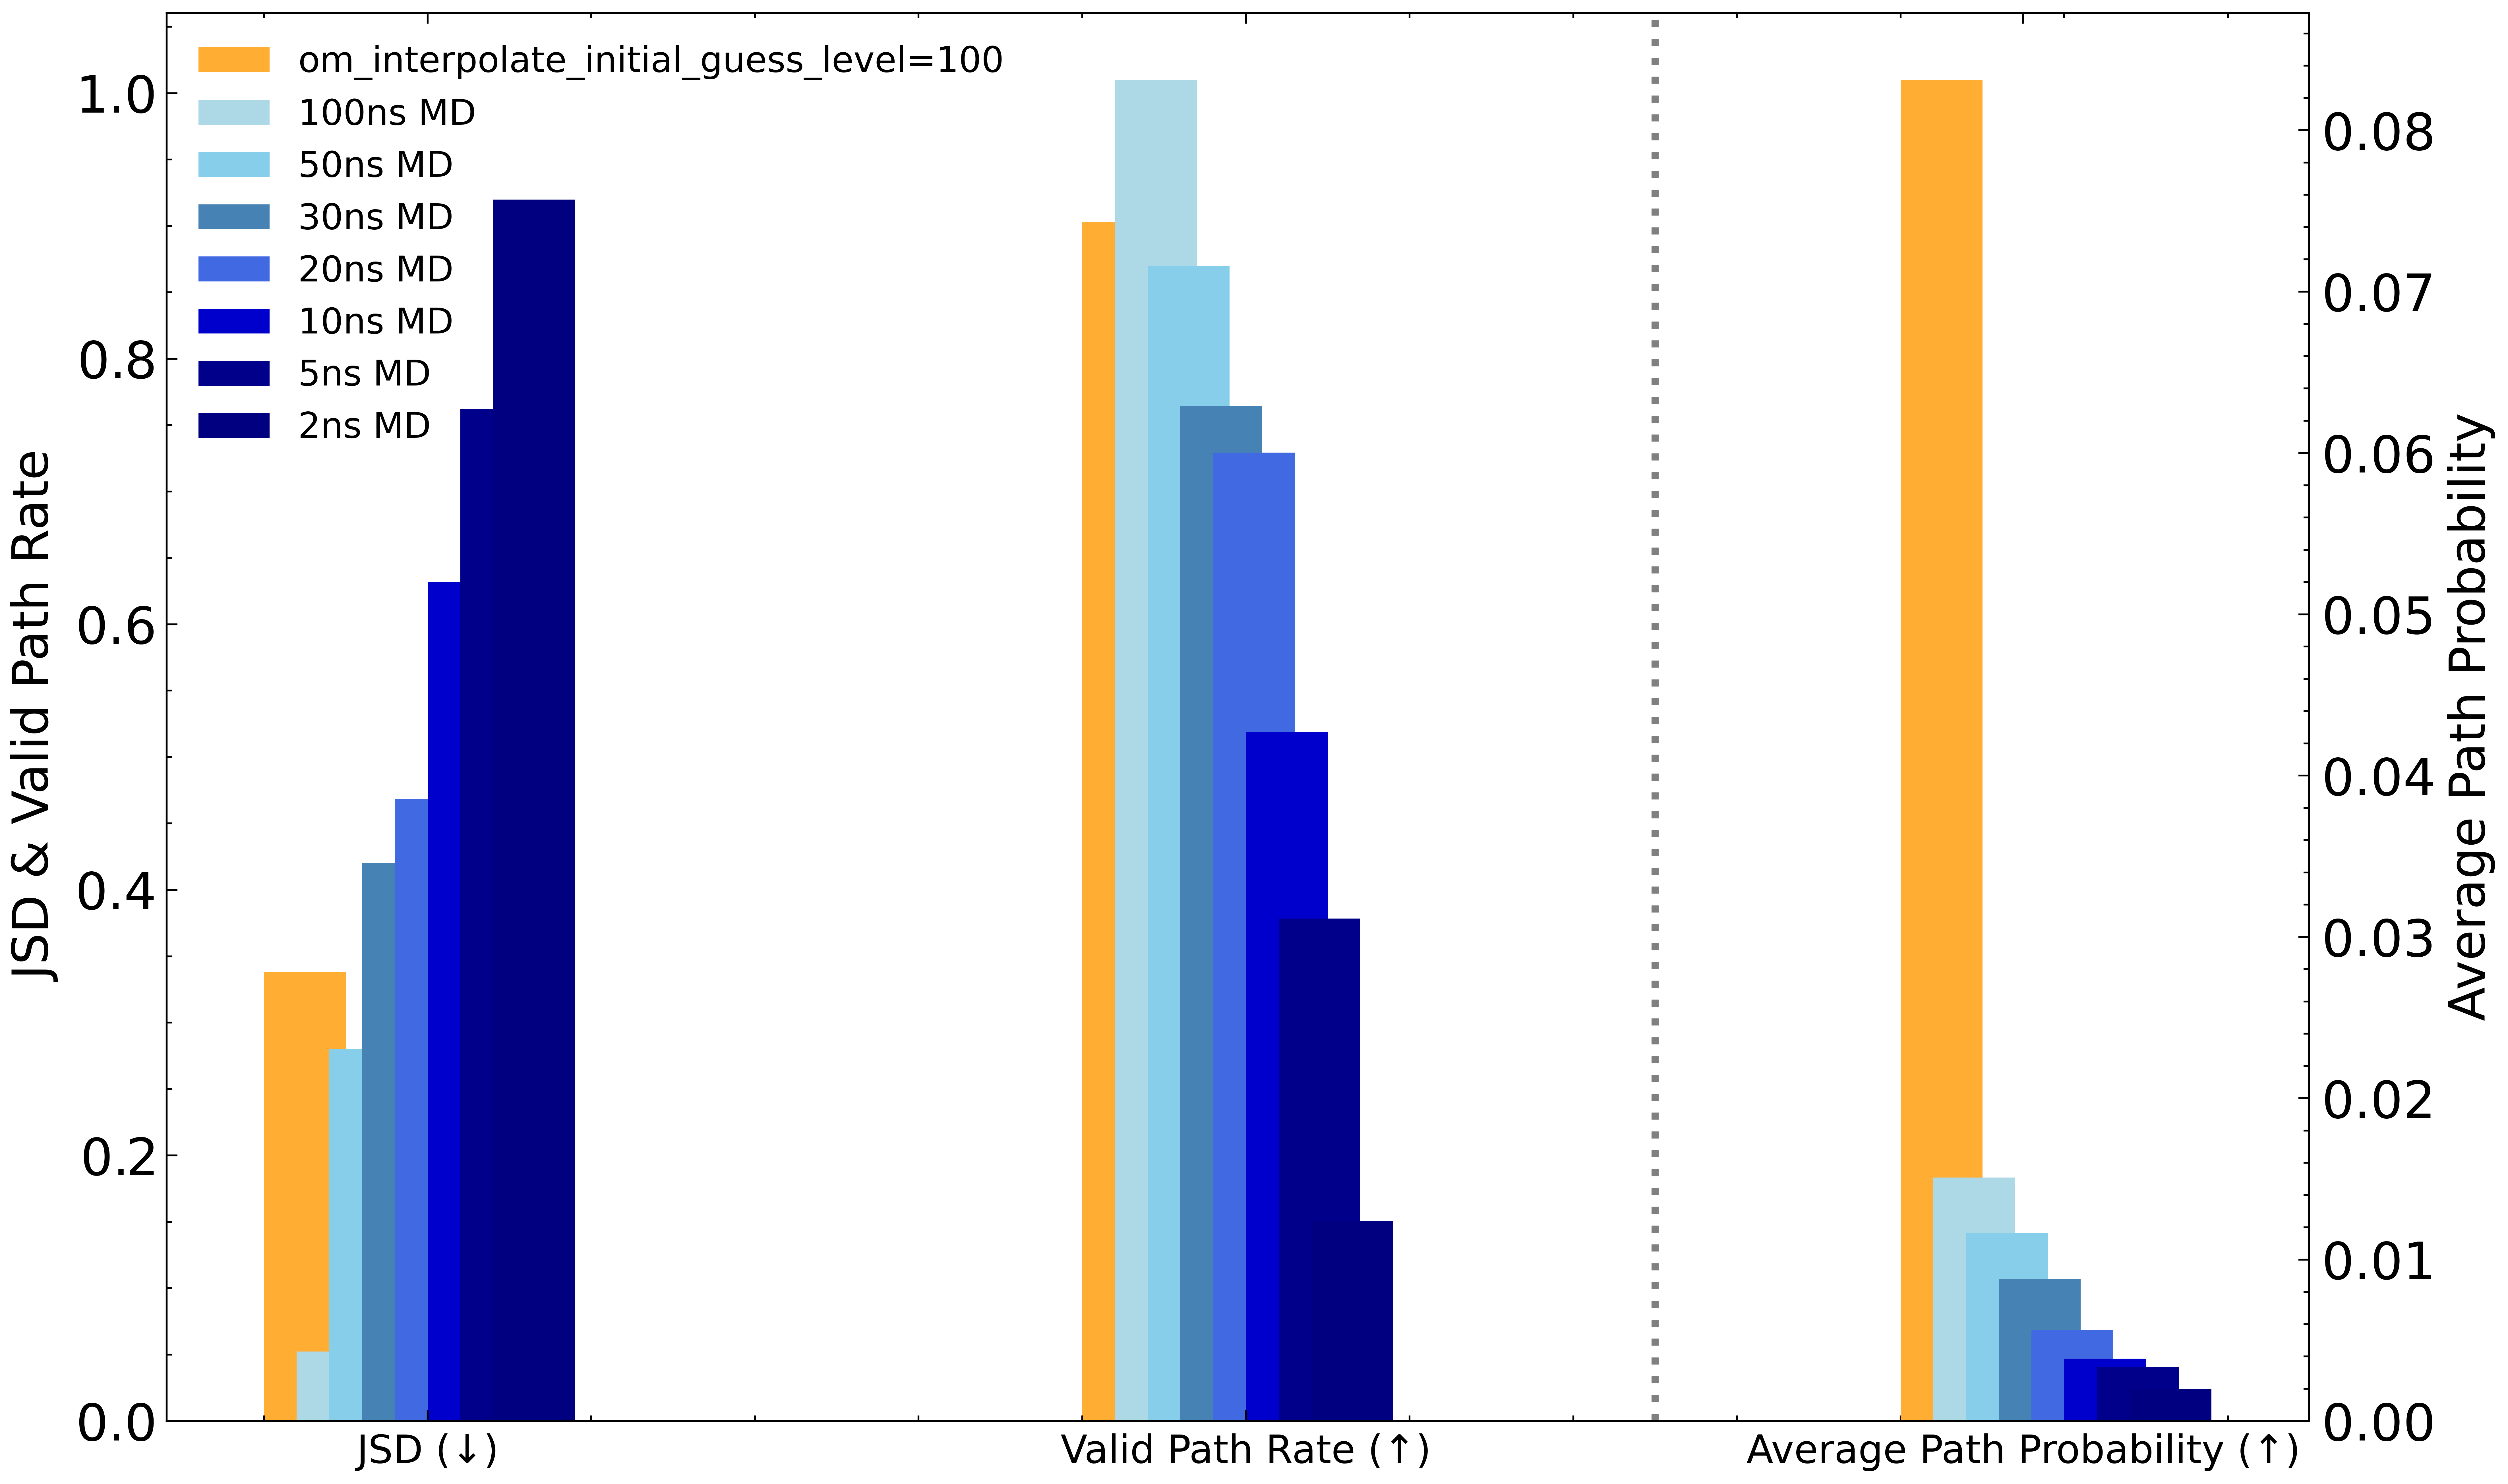

In [3]:
# names = ['interpolate_latent_time=0', 'interpolate_latent_time=100', 'om_interpolate_initial_guess_level=0', 'om_interpolate_initial_guess_level=100']
names = ['om_interpolate_initial_guess_level=100'] #, 'om_interpolate_initial_guess_level=250'] #, 'interpolate_latent_time=100']
results_dir = 'saved_models/tetrapeptides'
split = "mdgen/splits/4AA_test_small.csv"
make_tetrapeptide_figures(names, results_dir, split, "tetra_figure")